In [1]:
import numpy as np
import matplotlib.pyplot as plt
import arviz as az
import dill

## Load results

In [2]:
run_id = 100
names = ['bootstrap_icsmc', 'guided_icsmc', 'reparameterised_icsmc_bs']

icsmc_bootstrap = az.from_netcdf(f'./results/run_{run_id}_bootstrap_icsmc.nc')
icsmc_guided = az.from_netcdf(f'./results/run_{run_id}_guided_icsmc.nc')
icsmc_reparameterised = az.from_netcdf(f'./results/run_{run_id}_reparameterised_icsmc_bs.nc')

with open(f'./results/run_{run_id}_meta.pkl', 'rb') as f:
    metadata = dill.load(f)

idata_dict = {'Boot-iCSMC': icsmc_bootstrap, 'BwG-iCSMC': icsmc_guided, 'BwG-iCSMC-BS': icsmc_reparameterised}

# Unpack the metadata
x, y = metadata['x'], metadata['y']
cdssm = metadata['cdssm']

Nx = icsmc_bootstrap.attrs['Nx']
num = icsmc_bootstrap.attrs['num']
model_sde = icsmc_bootstrap.attrs['model_sde']    
niter = icsmc_bootstrap.attrs['niter']

T = len(y)
S = cdssm.s_ts * T

times = times = np.linspace(start=0., stop=S, num=(num*T + 1))[1:]
obs_times = np.linspace(start=0., stop=S, num=(T+1))[1:]

print(f'Model: {model_sde}, Nx: {Nx}, num: {num}, T={T}, delta_s = {cdssm.s_ts}, S={S}')

Model: IntegratedFitzhughNagumo, Nx: 50, num: 50, T=100, delta_s = 0.05, S=5.0


## Figure 6: Update rates of across chains and Effective Sample Size (ESS) for both components

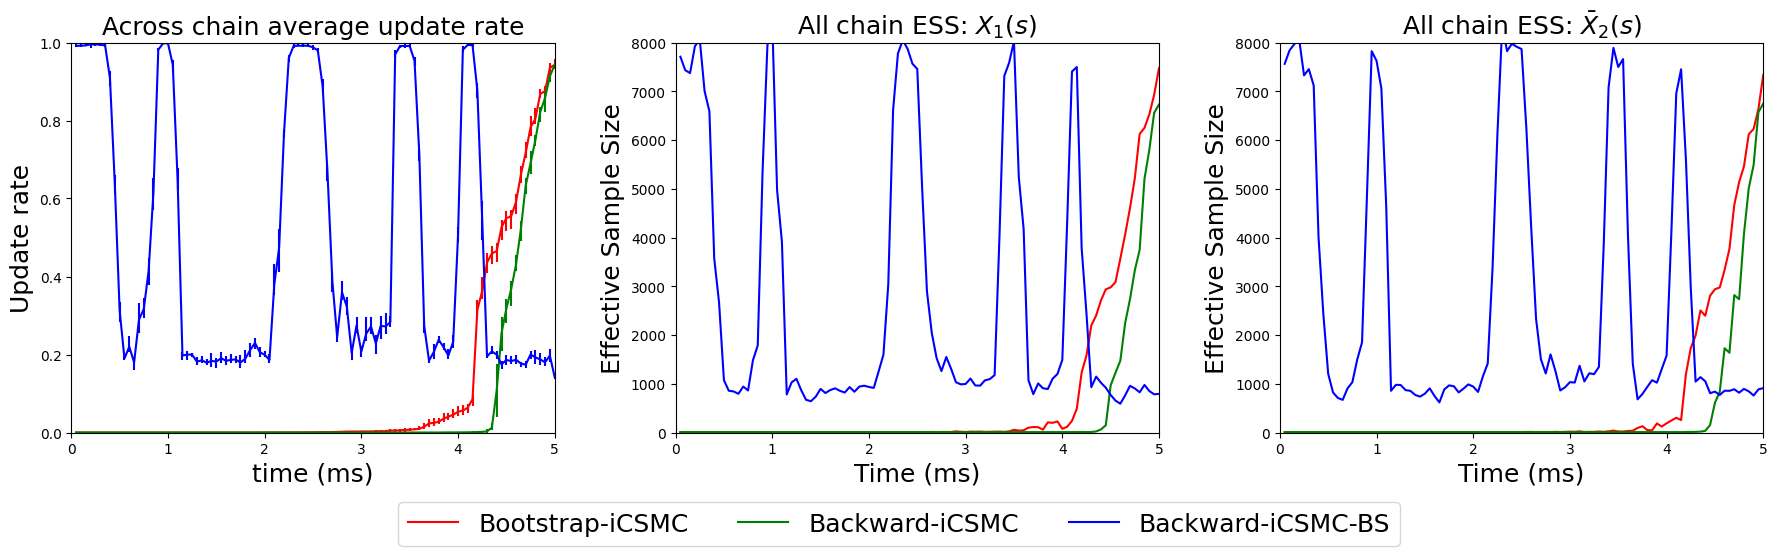

In [3]:
algs = [icsmc_bootstrap, icsmc_guided, icsmc_reparameterised]
labels = ['Bootstrap-iCSMC', 'Backward-iCSMC', 'Backward-iCSMC-BS']
colors = ['red', 'green', 'blue']
titles = [r'$X_1(s)$', r'$\bar{X}_2(s)$']

times = np.linspace(0., S, num=T+1)[1:]
fig, _axes = plt.subplots(1, 3, figsize=(18, 6), sharey=False)

axes = _axes[1:]

for i in range(3):
    for j in range(2):
        bulk_ess = az.ess(algs[i].posterior, method='bulk')
        bulk_ess_vals = bulk_ess['x'].values
        axes[j].plot(times, bulk_ess_vals[:, j], color=colors[i], label=labels[i])
        axes[j].set(xlim=(0., 5.), ylim=(0, 8000), ylabel='Effective Sample Size', xlabel='Time (ms)', title='All chain ESS: ' + titles[j])

ax = _axes[0]

for i in range(3):
    X = algs[i].posterior['x'].values
    X_isupdated = 1.*(X[:, 1:] != X[:, :-1])
    X_update_rates = X_isupdated.mean(axis=1)[:, :, 0] # (8, 100)
    avg_update_rate = X_update_rates.mean(axis=0) # (100, )
    max_update_rate = X_update_rates.max(axis=0) # (100, )
    min_update_rate = X_update_rates.min(axis=0) # (100, )
    yerr = np.stack([avg_update_rate - min_update_rate, max_update_rate - avg_update_rate], axis=0)
    ax.errorbar(times, avg_update_rate, yerr=yerr, linestyle='-', color=colors[i], label=labels[i])

ax.set(xlabel='time (ms)', ylabel='Update rate', title='Across chain average update rate', xlim=(0., S), ylim=(0., 1.))

for ax in _axes:
    ax.title.set_fontsize(18)
    ax.xaxis.label.set_fontsize(18)
    ax.yaxis.label.set_fontsize(18)

fig.subplots_adjust(left=0.04, right=0.98, bottom=0.23, wspace=0.25)
h, l = axes[0].get_legend_handles_labels()
fig.legend(h, l,
           loc='lower center',
           bbox_to_anchor=(0.5, 0.02),
           ncol=len(h),
           fontsize=18)

plt.savefig('./figures/fig_6_fhn_results.pdf', dpi=600)

## Figure 7: R-Hat Diagnostic for both components

/Users/chris_stanton/code/particles_cdssm_workspace/particles-cdssm/venv/particles_cdssm/lib/python3.11/site-packages/arviz/stats/diagnostics.py:595: RuntimeWarning: invalid value encountered in sqrt
  rhat_value = np.sqrt(


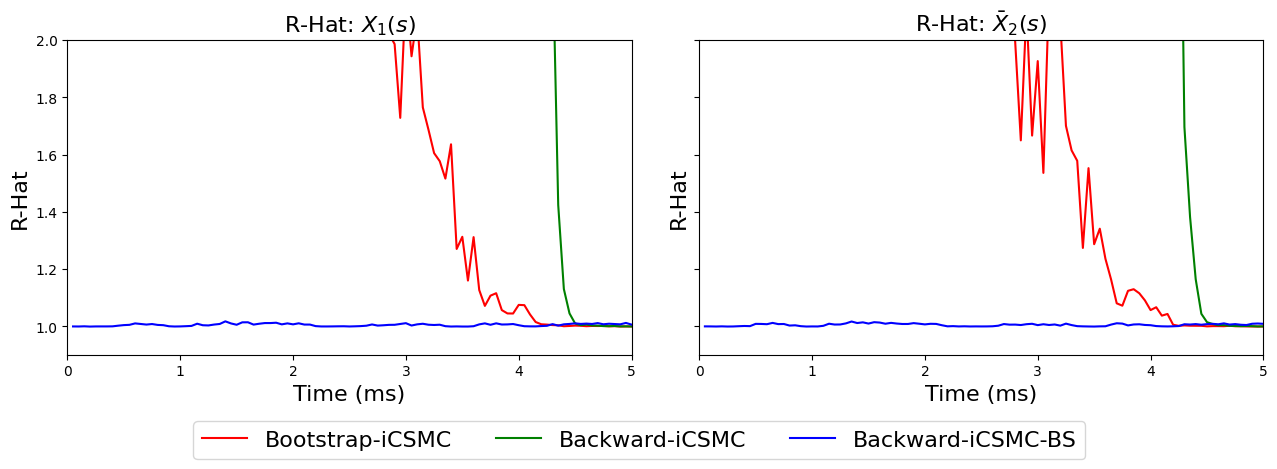

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

for i in range(3):
    for j in range(2):
        rhat = az.rhat(algs[i].posterior)
        rhat_values = rhat['x'].values
        axes[j].plot(times, rhat_values[:, j], color=colors[i], label=labels[i])
        axes[j].set(ylabel='R-Hat', xlabel='Time (ms)', title='R-Hat: ' + titles[j])
        axes[j].set_xlim((0.0, 5.0))
        axes[j].set_ylim((0.9, 2.0))
        
for ax in axes:
    ax.title.set_fontsize(16)
    ax.xaxis.label.set_fontsize(16)
    ax.yaxis.label.set_fontsize(16)

fig.subplots_adjust(left=0.06, right=0.98, bottom=0.25, wspace=0.12)
h, l = axes[0].get_legend_handles_labels()
fig.legend(h, l,
           loc='lower center',
           bbox_to_anchor=(0.5, 0.02),
           ncol=len(h),
           fontsize=16)

plt.savefig('./figures/fig_7_r_hat_results.pdf')
plt.show()